# Summary: what the three systems say, and what was built to make them say it

**The two workflows, named in full once.** **SS-CASSCF Berry-phase loop transport** ("loop
transport") continues a *state-specific* CASSCF ground state around a closed nuclear loop and reads
a Z2 Berry phase from the sign of the initial–final nonorthogonal overlap. The **SA-CASSCF gap
scan** ("gap scan") puts equal-weight *state-averaged* CASSCF on a grid over the enclosed region and
reports where the S1–S0 gap is smallest. "Berry phase" means the quantity loop transport returns,
not the method.

This notebook is the short cross-system view. The detail is elsewhere:

| notebook | what it covers |
|---|---|
| `formaldimine_benchmark.ipynb` | the primary benchmark, calibrated against FCI |
| `ethylene_ladder.ipynb` | an active-space ladder **with** an exact in-basis reference |
| `butadiene_ladder.ipynb` | a ladder with **no** reference, and the open question |
| `adaptive_stepping.ipynb` | how the loop chooses its own discretization, and when that pays |
| `locating_intersections.ipynb` | turning one bit per loop into a position |
| `stepping_comparison.ipynb` | one update per point versus optimizing to convergence |

In [1]:
import glob, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from berrycasscf.refine import cone_apex
from berrycasscf.scan import ScanResult

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

ETH = os.path.join(ROOT, "results", "ethylene")
BUTA = os.path.join(ROOT, "results", "butadiene")
LADDER = [(2, 2), (4, 4), (6, 6), (8, 8), (10, 10), (12, 12)]

def load_first(pattern):
    for p in sorted(glob.glob(pattern)):
        r = ScanResult.load(p)
        if np.isfinite(r.e_states).all():
            return r
    return None

def coarse_apex(scan):
    i = int(np.unravel_index(np.nanargmin(scan.gap), scan.gap.shape)[0])
    return cone_apex(scan.phis, scan.gap[i] * 1e3, window=3)

def fine_apex(ne, ncas):
    p = os.path.join(BUTA, f"butadiene_refinepyr_cas{ne}-{ncas}.npz")
    if os.path.exists(p):
        r = ScanResult.load(p)
        if np.isfinite(r.e_states).all():
            return cone_apex(r.phis, r.gap[0] * 1e3, window=None)
    return None

eth = {c: load_first(os.path.join(ETH, f"ethylene_scan_cas{c[0]}-{c[1]}_*.npz")) for c in LADDER}
buta = {c: load_first(os.path.join(BUTA, f"butadiene_scan_cas{c[0]}-{c[1]}_*.npz"))
        for c in LADDER}
print("ethylene scans :", ", ".join(f"CAS{c}" for c, r in eth.items() if r is not None))
print("butadiene scans:", ", ".join(f"CAS{c}" for c, r in buta.items() if r is not None))

ethylene scans : CAS(2, 2), CAS(4, 4), CAS(6, 6), CAS(8, 8), CAS(10, 10), CAS(12, 12)
butadiene scans: CAS(2, 2), CAS(4, 4), CAS(6, 6), CAS(8, 8), CAS(10, 10), CAS(12, 12)


## 1. The central result: the intersection position drifts, and not monotonically

The gap scan's estimate of *where* the intersection is moves with the active space — on two of
three systems, **enlarging the active space made the answer worse** at intermediate rungs, which
breaks the heuristic everyone actually uses.

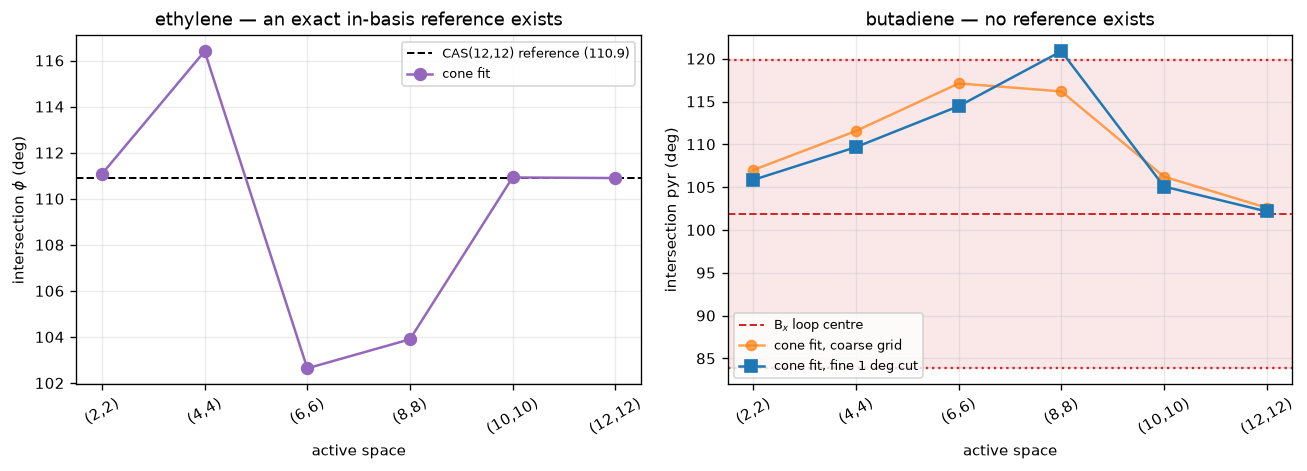

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

ax = axes[0]
xs, ys = [], []
for k, cas in enumerate(LADDER):
    r = eth.get(cas)
    if r is None: continue
    xs.append(k); ys.append(coarse_apex(r).position)
if xs:
    ax.axhline(ys[-1], color="k", ls="--", lw=1.2, label=f"CAS(12,12) reference ({ys[-1]:.1f})")
    ax.plot(xs, ys, "o-", ms=7, color="tab:purple", label="cone fit")
ax.set_xticks(range(len(LADDER)))
ax.set_xticklabels([f"({a},{b})" for a, b in LADDER], rotation=30)
ax.set_xlabel("active space"); ax.set_ylabel(r"intersection $\phi$ (deg)")
ax.set_title("ethylene — an exact in-basis reference exists"); ax.legend(fontsize=7.5)

ax = axes[1]
xs, ys, fine = [], [], []
for k, cas in enumerate(LADDER):
    r = buta.get(cas)
    if r is None: continue
    f = fine_apex(*cas)
    xs.append(k); ys.append(coarse_apex(r).position)
    fine.append(f.position if f is not None else np.nan)
if xs:
    lo, hi = 101.85 - 18.0, 101.85 + 18.0
    ax.axhspan(lo, hi, color="tab:red", alpha=0.10)
    ax.axhline(101.85, color="tab:red", ls="--", lw=1.2, label="B$_x$ loop centre")
    for edge in (lo, hi):
        ax.axhline(edge, color="tab:red", ls=":", lw=1.4)
    ax.plot(xs, ys, "o-", ms=6, color="tab:orange", alpha=0.7, label="cone fit, coarse grid")
    if np.isfinite(fine).any():
        ax.plot(xs, fine, "s-", ms=7, color="tab:blue", label="cone fit, fine 1 deg cut")
ax.set_xticks(range(len(LADDER)))
ax.set_xticklabels([f"({a},{b})" for a, b in LADDER], rotation=30)
ax.set_xlabel("active space"); ax.set_ylabel("intersection pyr (deg)")
ax.set_title("butadiene — no reference exists"); ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()

## 2. The verdict table

The distinction that matters is between **"gets the right answer"** and **"can be trusted without
already knowing the answer"**. They differ by four rungs on ethylene.

In [3]:
rows = [
    ("formaldimine", "CAS(2,2)", "CAS(4,4)", "CAS(4,4)", "FCI in basis (alpha_x = 132.6 deg)"),
    ("ethylene",     "CAS(2,2)", "CAS(2,2)", "CAS(10,10)", "CAS(12,12) full valence"),
    ("butadiene",    "CAS(2,2)", "n/a (no reference)", "none on the ladder",
     "none: full valence is CAS(22,22)"),
]
print(f"{'system':>13} {'loop transport':>15} {'gap scan accurate':>19} "
      f"{'gap scan stable':>17}   reference")
print("-" * 104)
for r in rows:
    print(f"{r[0]:>13} {r[1]:>15} {r[2]:>19} {r[3]:>17}   {r[4]}")
print()
print("'accurate' = lands near the reference.  'stable' = enlarging the space stops moving it,")
print("which is the only test a practitioner can actually apply without a reference.")

       system  loop transport   gap scan accurate   gap scan stable   reference
--------------------------------------------------------------------------------------------------------
 formaldimine        CAS(2,2)            CAS(4,4)          CAS(4,4)   FCI in basis (alpha_x = 132.6 deg)
     ethylene        CAS(2,2)            CAS(2,2)        CAS(10,10)   CAS(12,12) full valence
    butadiene        CAS(2,2)  n/a (no reference) none on the ladder   none: full valence is CAS(22,22)

'accurate' = lands near the reference.  'stable' = enlarging the space stops moving it,
which is the only test a practitioner can actually apply without a reference.


**No active-space recipe transferred between the three systems.** Formaldimine's comparator is
*qualitatively* wrong at CAS(2,2) — it reports a near-degeneracy inside a trivial loop and finds
nothing inside the true one — and converged by CAS(4,4). Ethylene's is accurate at CAS(2,2) by
accident and not stable until CAS(10,10). Butadiene's never settles: the position spans 19.2° and
the top two rungs still differ by 3.2°.

What *did* transfer is the procedure: enlarge the space until the answer stops moving, and check an
exact symmetry of the system to confirm the solver is not the thing that moved.

**Loop transport returned the correct topology at every rung of every system tested, CAS(2,2)
included.** What grows with the active space is not its error but the *discretization* it needs.
That is the core asymmetry: a topological question tolerates a badly misplaced intersection as long
as the loop still encloses it.

## 3. The sharpest open question

At butadiene CAS(12,12) the two methods are hardest to reconcile. A direct 2D search finds no gap
below **1.5 mHa** anywhere in the loop's area — where the same search drives every other rung to
~0.005 mHa, some 300× lower — while loop transport returns **π** on that same loop, stable at two
discretizations with endpoint overlap −1.000000.

Both objections to reading that as a disagreement have been tested and answered: the floor is not a
line-fitting artifact (a free 2D search gets only 16% below it), and it is not an intersection
hiding off the sampled cross (a 5×5 grid over the loop area has its minimum at the centre).

**But it is still not "there is no intersection there".** 1.5 mHa is 0.04 eV, inside the error of
the model itself, so a surface that genuinely touches could present a floor that size. Settling it
needs a criterion for when a state-averaged minimum gap is compatible with a true crossing — which
this work has not established — or a direct measurement of what loop transport is encircling, which
is what `locating_intersections.ipynb` is for.

## 4. What was built, and what it cost to find out

Three methodological additions, each with a notebook:

* **Binding continuity checks.** A "continuation chain broken" diagnostic was reported for most of
  this project and never acted on. It is now a check, chosen by calibrating all 116 saved runs
  against self-consistency rather than by taste: with it on, no overlap threshold from 0.70 to 0.92
  admits a contradiction; with it off, 0.80 admits a lone dissenter and 0.70 an outright
  contradiction.
* **Adaptive step control.** Measured honestly, it is **cost-neutral** on the loops tested. Its
  value is that it walks loops uniform discretization cannot walk at any affordable $N$, removes
  the need to guess $N$, and diagnoses *why* a loop failed.
* **Bisection and triangulation.** A method returning one bit per loop can return a position, with
  a measured resolution and a built-in consistency check.

Three of this project's own claims were overturned by checking them, and the checks are recorded
next to the claims in `docs/findings.md` rather than quietly corrected.